# Step 1.5: RocketPy 기반 시뮬레이션 데이터 생성하기

## 목표

1. 데이터 부족 문제 해결: 실제 비행 데이터 2 개만으로는 AI 학습이 불가능함. RocketPy 기반 몬테카를로 시뮬레이션으로 대량 데이터셋 생성
2. Step 1 이론과의 연계: 분산 (1.2), 공분산 (1.4), 가우시안 분포 (2), 상태방정식 (3.1) 을 시뮬레이션 설계에 명시적으로 반영
3. AI 학습용 포맷 제공: Step 2~6 에서 바로 사용할 수 있도록, 입력 (상태 시퀀스) 과 라벨 (아포지 고도/시간) 이 정제된 데이터셋 출력

## Step 1 이론 연계

| Step 1 챕터 | 시뮬레이션 적용 내용 |
|----------|---------------------|
| **1.2 분산 (Variance)** | 센서 노이즈 모델링, 환경 변수 변동성 |
| **1.4 공분산 (Covariance)** | 다변량 센서 간 상관관계, 공분산 행렬 기반 노이즈 |
| **2. 가우시안 분포** | 몬테카를로 샘플링의 수학적 기반 |
| **3.1 상태방정식** | RocketPy 내부 궤적 계산의 물리적 기반 |

---

## 데이터 유형별 용도

| 데이터 유형 | 용도 | 학습 포함 여부 |
|------------|------|---------------|
| **시뮬레이션 데이터** | AI 모델 학습 (Train/Validation) | 포함 |
| **실제 비행 데이터 (2 개)** | 최종 성능 검증 (Test) | **제외** (Domain Gap 평가용) |

In [1]:
import numpy as np
import pandas as pd
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
from scipy import stats
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
import multiprocessing as mp
import warnings
import rocketpy
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (그래프 출력용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정 (재현성 확보)
np.random.seed(42)

# 디렉토리 설정
OUTPUT_DIR = './data/simulated/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("라이브러리 로드 완료")
print(f"출력 디렉토리: {OUTPUT_DIR}")
print(f"사용 가능한 CPU 코어: {cpu_count()} 개")

라이브러리 로드 완료
출력 디렉토리: ./data/simulated/
사용 가능한 CPU 코어: 12 개


## 1. 로켓 및 모터 설정 (Step 1 3.1 상태방정식 연계)

### 물리 파라미터의 의미

RocketPy 에 설정하는 파라미터들은 **Step 1 3.1 상태방정식**의 변수들과 직접 연결됨:

$$ m(t)\dot{v} = T(t) - \frac{1}{2}\rho v^2 C_d A - m(t)g $$

| 파라미터 | 상태방정식 변수 | 물리적 의미 |
|----------|----------------|-------------|
| 질량 (mass) | $m(t)$ | 연소에 따라 시간에 따라 변화 |
| 추력 (thrust) | $T(t)$ | 모터 성능 곡선 (.eng 파일) |
| 항력계수 (Cd) | $C_d$ | 공기저항 계수 (미지수, Step 4 에서 추정) |
| 단면적 (area) | $A$ | 로켓 직경으로 계산 |
| 공기밀도 (rho) | $\rho$ | 고도에 따라 변화 |

OpenRocket 시뮬레이션을 통해 얻은 .eng 파일을 사용하거나, PSI 연소실험을 통해 얻은 압력 데이터를 가지고 .eng 파일을 생성하는 아래 코드셀을 활용할 것.

In [2]:
#압력 → 추력 변환
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pressure_to_thrust(pressure_bar, time_millisec, nozzle_params, C_F=1.627):
    """
    챔버 압력 데이터를 추력 데이터로 변환
    
    Parameters:
        pressure_bar: 챔버 압력 (bar)
        time_sec: 시간 (ms)
        nozzle_params: 노즐 파라미터 딕셔너리
        C_F=1.627 : 241114 연소실험 데이터를 바탕으로 역산한 값. 더 정확한 식을 사용하거나, 연소실험에 따라 변경 권고.
    
    Returns:
        thrust_N: 추력 (N)
    """
    # 노즐 파라미터 추출
    throat_diameter = nozzle_params['throat_diameter']  # m
    exit_diameter = nozzle_params['exit_diameter']  # m
    exit_angle = nozzle_params['exit_angle']  # degree
    gamma = 1.2  # 비열비 (고체추진제)
    Pc_to_Pe_ratio = 50  # 챔버/배기 압력비 (추정) <- 추후 수정 필요
    
    # 스로트 단면적
    A_t = np.pi * (throat_diameter / 2) ** 2
    
    # 압력 → 추력 변환 (bar → Pa)
    pressure_Pa = pressure_bar * 1e5
    thrust_N = C_F * A_t * pressure_Pa
    
    return thrust_N

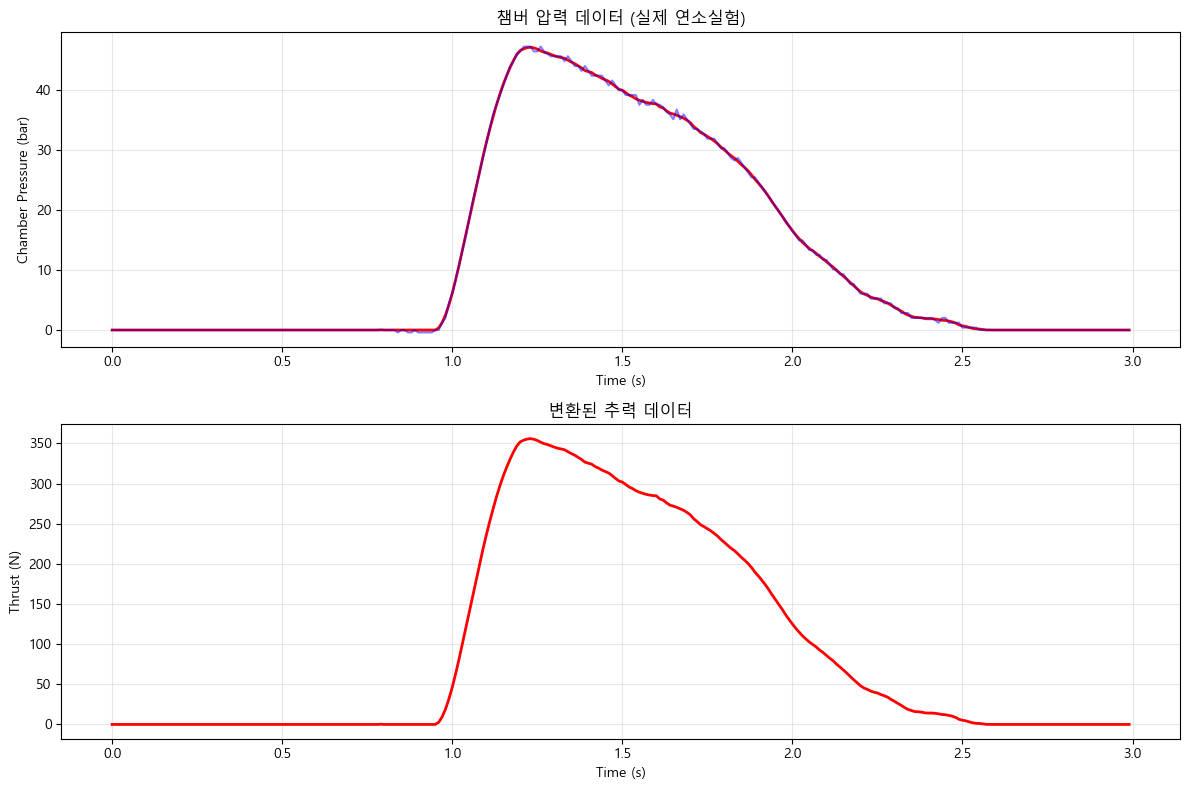

추력 곡선 통계 (압력 데이터 변환)
최대 추력: 356.07 N
평균 추력: 95.59 N
연소 시간: 2.99 s
총 임펄스: 286.77 N·s


In [3]:
# 실제 압력 데이터 로드 및 변환
from scipy.signal import savgol_filter

pressure_data = pd.read_csv('./data/motor/241114.csv')
# columns: ['time', 'pressure']

# 2. 노즐 파라미터
nozzle_params = {
    'throat_diameter': 0.007692,  # 7.692mm → m
    'exit_diameter': 0.019806,    # 19.806mm → m
    'exit_angle': 35,             # degree
    'expansion_ratio': 6.63,
}

pressure_raw = pressure_data['pressure'].values

# Savitzky-Golay 필터로 노이즈 제거
pressure_smooth = savgol_filter(pressure_raw, window_length=11, polyorder=3)

# 음수 값 제거
pressure_smooth = np.maximum(pressure_smooth, 0)

# 전처리 후 데이터 저장
pressure_data['pressure_smooth'] = pressure_smooth
pressure_data['time_sec'] = pressure_data['time']/1000

# 3. 압력 → 추력 변환
thrust_N = pressure_to_thrust(
    pressure_data['pressure_smooth'].values,
    (pressure_data['time_sec'].values),
    nozzle_params
)

# 4. 결과 저장 (추력 곡선)
thrust_curve = pd.DataFrame({
    'time_sec': pressure_data['time_sec'],
    'thrust_N': thrust_N
})
thrust_curve.to_csv('./data/motor/thrust_curve_from_pressure.csv', index=False)

# 5. 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(pressure_data['time_sec'], pressure_data['pressure_smooth'], 'r-', linewidth=2, label='Filtered')
axes[0].plot(pressure_data['time_sec'], pressure_raw, 'b-', alpha=0.5, label='Raw')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Chamber Pressure (bar)')
axes[0].set_title('챔버 압력 데이터 (실제 연소실험)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(thrust_curve['time_sec'], thrust_curve['thrust_N'], 'r-', linewidth=2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Thrust (N)')
axes[1].set_title('변환된 추력 데이터')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/motor/pressure_to_thrust_conversion.png', dpi=150)
plt.show()

# 6. 추력 통계 출력
print("="*70)
print("추력 곡선 통계 (압력 데이터 변환)")
print("="*70)
print(f"최대 추력: {thrust_curve['thrust_N'].max():.2f} N")
print(f"평균 추력: {thrust_curve['thrust_N'].mean():.2f} N")
print(f"연소 시간: {thrust_curve['time_sec'].max():.2f} s")
print(f"총 임펄스: {np.trapz(thrust_curve['thrust_N'], thrust_curve['time_sec']):.2f} N·s")
print("="*70)

 SolidMotor 생성

모터 정보:
   건조 질량: 0.303 kg (float)
   연료 초기 질량: 0.479 kg
   최대 추력: 356.1 N
   연소 시간: 2.99 s
   총 임펄스: 286.8 N·s
   초기값 (t=0): 0.479 kg
   연소 후 (t=5): 0.000 kg

모터 정보:
   최대 추력: 356.1 N
   연소 시간: 2.99 s
   총 임펄스: 286.8 N·s
Nozzle Details
Nozzle Radius: 0.009903 m
Nozzle Throat Radius: 0.003846 m

Grain Details
Number of Grains: 2
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.0265 m
Grain Inner Radius: 0.0075 m
Grain Height: 0.065 m
Grain Volume: 0.000 m3
Grain Mass: 0.239 kg

Motor Details
Total Burning Time: 2.99 s
Total Propellant Mass: 0.479 kg
Structural Mass Ratio: 0.388
Average Propellant Exhaust Velocity: 598.879 m/s
Average Thrust: 95.911 N
Maximum Thrust: 356.06759613572405 N at 1.23 s after ignition.
Total Impulse: 286.775 Ns



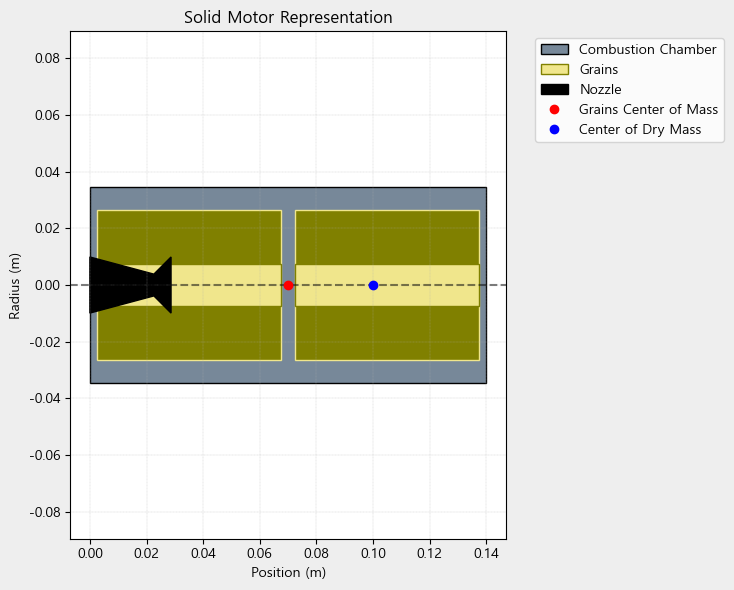

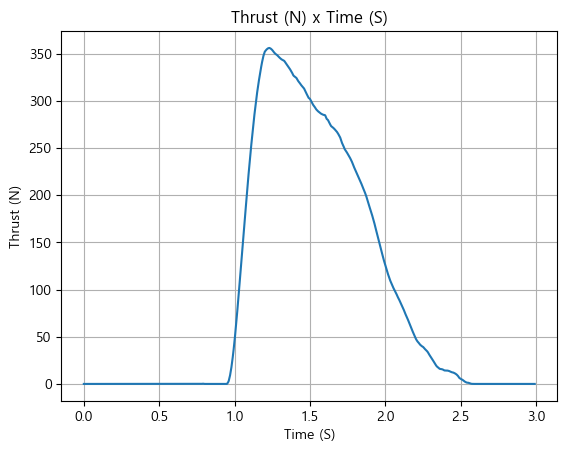

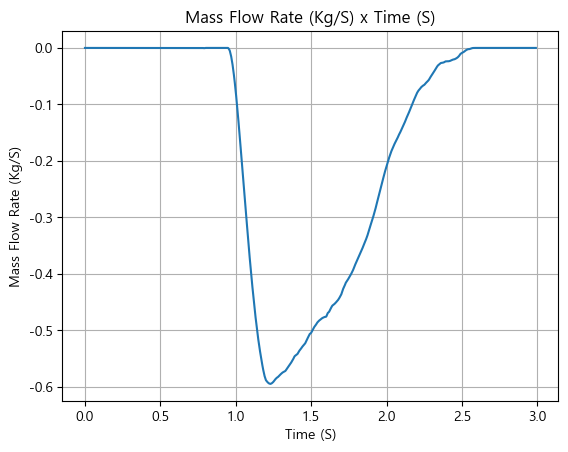

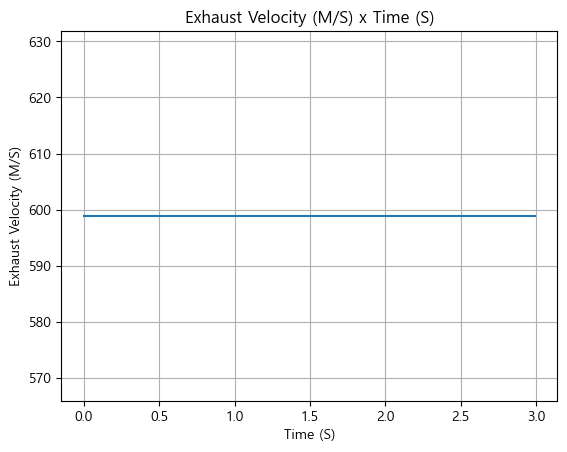

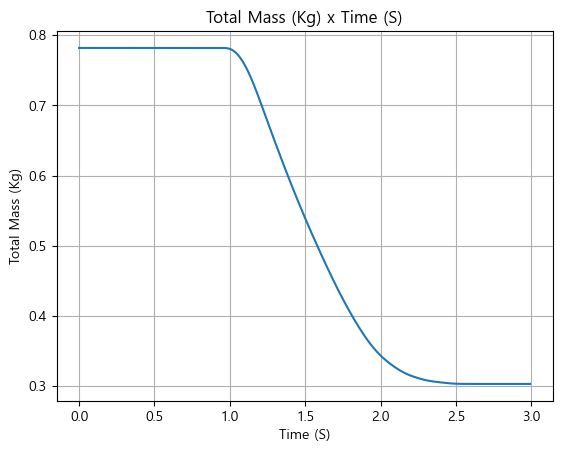

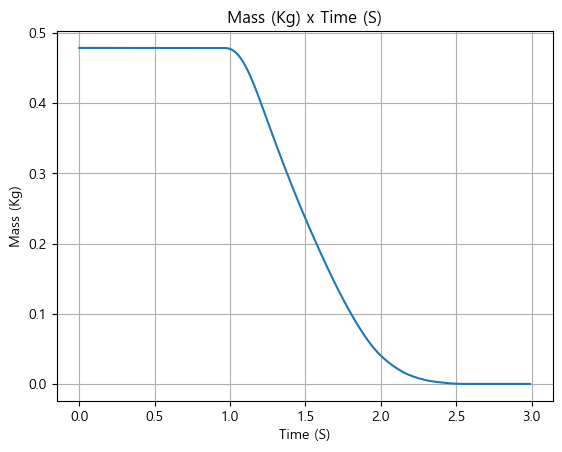

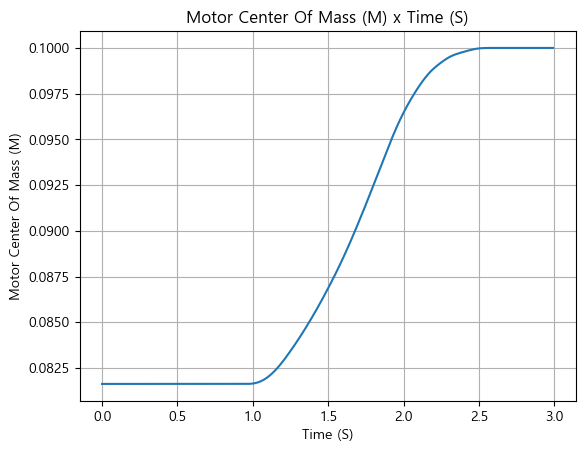

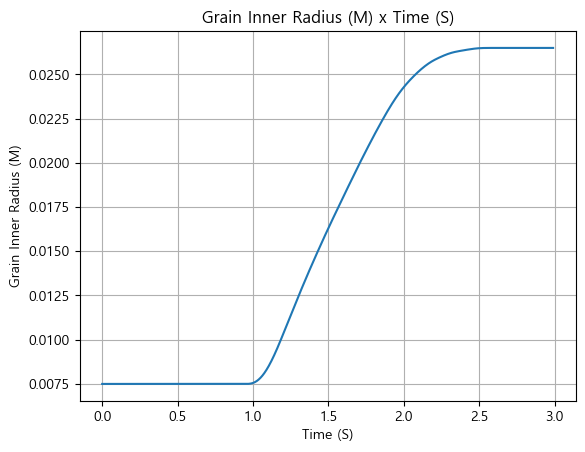

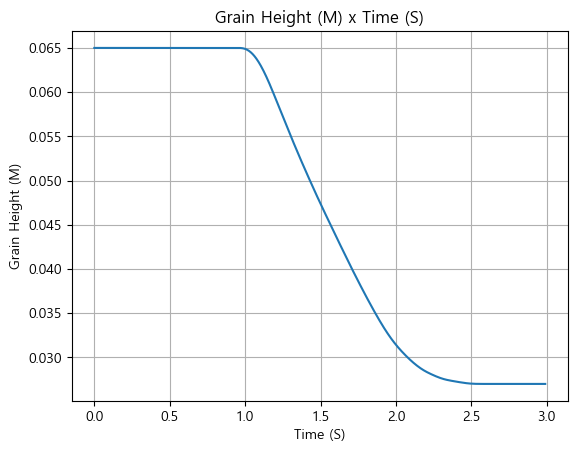

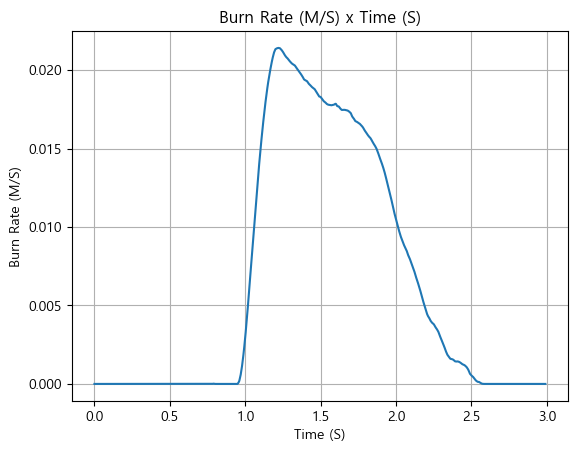

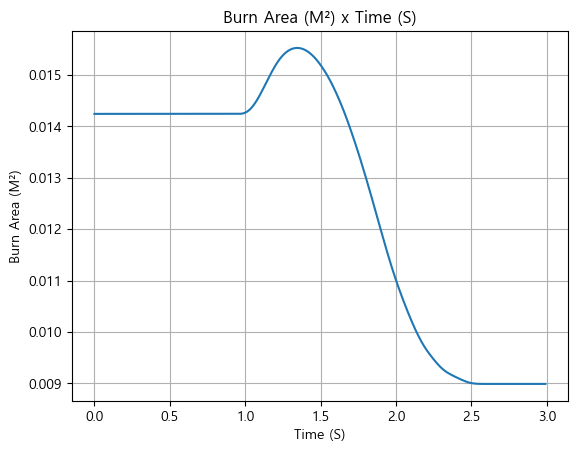

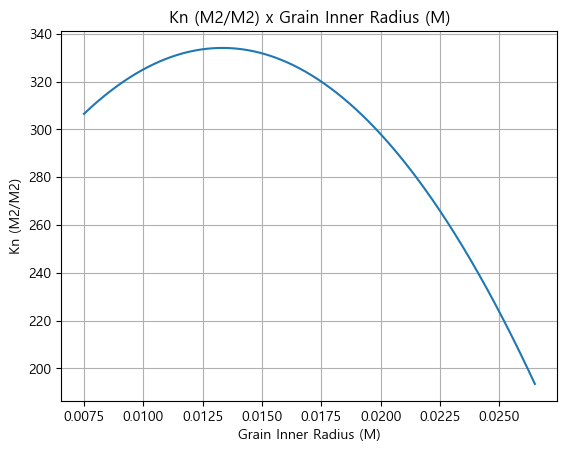

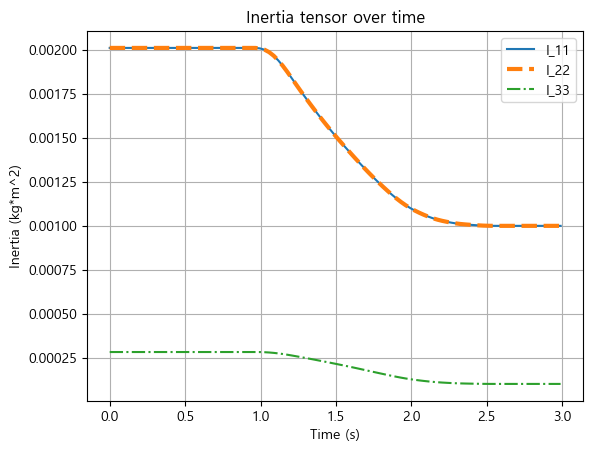

In [4]:
from rocketpy import SolidMotor, Function, Rocket

# 연소실험 데이터 로드
thrust_csv = './data/motor/thrust_curve_from_pressure.csv' # 이전 셀에서 지정한 경로와 같아야 함

# CSV 를 Function 으로 변환
thrust_function = Function(
    source=thrust_csv,
    inputs="Time (s)",
    outputs="Thrust (N)",
    interpolation="linear",
    extrapolation="constant"
)

if os.path.exists(thrust_csv):
    
    motor = SolidMotor(
        thrust_source=thrust_function,
        
        # 그레인 파라미터
        dry_mass=0.303,  # 체임버 질량 303g (케이스만)
        dry_inertia=(0.001, 0.001, 0.0001),
        
        # 그레인 정보 (2 개 그레인)
        grain_number=2,
        grain_density=1815,  # 고체추진제 밀도 (kg/m³)
        grain_outer_radius=0.0265,  # 외경 53mm / 2
        grain_initial_inner_radius=0.0075,  # 내경 15mm / 2
        grain_initial_height=0.065,  # 높이 65mm
        grain_separation=0.005,  # 그레인 간격 5mm
        
        # 그레인 질량 중심 위치
        grains_center_of_mass_position=0.07,  # 2 개 그레인 중심
        center_of_dry_mass_position=0.10,
        
        # 노즐 정보
        nozzle_radius=0.009903,  # 출구 직경 19.806mm / 2
        nozzle_position=0.0,
        throat_radius=0.003846,  # 스로트 직경 7.692mm / 2
        
        # 좌표계
        interpolation_method="linear",
        coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

    print(f" SolidMotor 생성")
    print(f"\n모터 정보:")
    print(f"   건조 질량: {motor.dry_mass} kg (float)")
    print(f"   연료 초기 질량: {motor.propellant_initial_mass:.3f} kg")
    print(f"   최대 추력: {motor.max_thrust:.1f} N")
    print(f"   연소 시간: {motor.burn_out_time:.2f} s")
    print(f"   총 임펄스: {motor.total_impulse:.1f} N·s")
    print(f"   초기값 (t=0): {motor.propellant_mass(0):.3f} kg")
    print(f"   연소 후 (t=5): {motor.propellant_mass(5):.3f} kg")
else:
    print("모터 파일이 없습니다. 테스트용 모터를 생성합니다.")
    
    # ThrustCurveMotor 로 대체 (Motor 는 추상 클래스이므로 직접 인스턴스화 불가)
    motor = SolidMotor(
        thrust_source=lambda x: 1 / (x + 1),
        dry_mass=1.815,
        dry_inertia=(0.125, 0.125, 0.002),
        center_of_dry_mass_position=0.317,
        grains_center_of_mass_position=0.397,
        burn_time=3.9,
        grain_number=5,
        grain_separation=5 / 1000,
        grain_density=1815,
        grain_outer_radius=33 / 1000,
        grain_initial_inner_radius=15 / 1000,
        grain_initial_height=120 / 1000,
        nozzle_radius=33 / 1000,
        throat_radius=11 / 1000,
        interpolation_method="linear",
        nozzle_position=0,
        coordinate_system_orientation="nozzle_to_combustion_chamber",
    )

# 모터 정보 출력
print(f"\n모터 정보:")
print(f"   최대 추력: {motor.max_thrust:.1f} N")
print(f"   연소 시간: {motor.burn_out_time:.2f} s")
print(f"   총 임펄스: {motor.total_impulse:.1f} N·s")

motor.all_info()

## 2. 로켓 물리 파라미터 정의

### 4kg 급 사운딩로켓 스펙 (동아리 실제 사양 기반)

| 파라미터 | 값 | 단위 | 비고 |
|----------|-----|------|------|
| 총 질량 | 5.0 | kg | 연료 포함 |
| 건조 질량 | 3.6 | kg | 연료 제외 |
| 연료 질량 | 0.4 | kg | 고체 추진제 |
| 직경 | 0.10 | m | 100mm |
| 길이 | 1.6 | m | |
| 항력계수 (Cd) | 0.6 | - | 초기 추정값 (Step 4 에서 보정) 

- 아래 코드에서 사용된 실제 핀, 노즈콘 등은 예제 https://docs.rocketpy.org/en/latest/examples/bella_lui_flight_sim.html
의 내용을 참고하였음. 
- 추후 시뮬레이션 데이터를 PSLV 용으로 수정할 경우 아래 코드 수정 권고

In [5]:
def add_aerodynamic_surfaces(rocket, radius=0.05, length=1.3, cant_angle=0.0):
    """
    로켓에 공기역학 표면 추가 (노즈, 핀)
    
    Parameters:
        rocket: RocketPy Rocket 객체
        radius: 로켓 반지름 (m)
        length: 로켓 전장 (m)
    
    Returns:
        rocket: 표면이 추가된 Rocket 객체
    """
    # 노즈 콘 추가
    nose_length = 0.3 
    rocket.add_nose(
        length=nose_length, 
        kind="ogive", # 실제 노즈콘에 맞춰 수정 권고
        position=0.8   # 무게중심에서 위로 80cm 지점에 노즈콘 팁이 위치 <- 마찬가지로 실제 로켓에 맞춰 수정
    )
    
    # 핀 추가
    # 코드 작성 편의를 위해 임의로 지정하였음
    fin_span = radius
    fin_root_chord = 0.12
    fin_tip_chord = 0.08
    fin_position = -0.20  # 질량 중심에서 뒤로 20cm
    
    rocket.add_trapezoidal_fins(
        n=4,
        span=fin_span,
        root_chord=fin_root_chord,
        tip_chord=fin_tip_chord,
        position=fin_position,
        cant_angle=cant_angle
    )
    
    return rocket

In [6]:
import numpy as np

def add_parachute(rocket, motor, Cd_drogue=0.8, lag_time=1.0):
    """
    로켓에 낙하산 장착
    """
    # 낙하산 추가
    rocket.add_parachute(
        "Drogue",
        cd_s=Cd_drogue,
        trigger="apogee",
        sampling_rate=100,
        lag=lag_time,
        noise=(0, 5.0, 0.5)
    )
    return rocket

In [7]:
def set_drag_coefficient_with_mach(rocket, Cd_data=None):
    """
    마하수에 따른 항력 계수 설정
    
    Parameters:
        rocket: RocketPy Rocket 객체
        Cd_ (마하수, Cd) 튜플 리스트 (없으면 기본값 사용)
    
    Returns:
        rocket: 항력 계수가 설정된 Rocket 객체
    """
    # 기본 데이터 (아음속 구간)
    if Cd_data is None:
        Cd_data = [
            (0.01, 0.51),
            (0.05, 0.50),
            (0.10, 0.48),
            (0.20, 0.45),
            (0.30, 0.43),
            (0.50, 0.46),
        ]
    
    # Function 객체 생성
    power_off_drag = Function(
        Cd_data,
        inputs=["Mach Number"],
        outputs="Drag Coefficient with Power Off",
        interpolation="linear",
        extrapolation="constant"
    )
    
    power_on_drag = Function(
        Cd_data,
        inputs=["Mach Number"],
        outputs="Drag Coefficient with Power On",
        interpolation="linear",
        extrapolation="constant"
    )
    
    # Rocket 객체에 적용
    rocket.power_off_drag = power_off_drag
    rocket.power_on_drag = power_on_drag
    
    return rocket

In [8]:
from rocketpy import Rocket, Function
import numpy as np

def create_rocket(motor, mass_total=5.2, mass_dry=4.3, diameter=0.10, length=1.3, Cd=0.6):
    """
    모터 스펙을 반영한 질량 관리 함수
    """
    radius = float(diameter) / 2.0
    
    # 1. 모터 실제 중량
    motor_prop = float(motor.propellant_initial_mass)
    motor_dry = float(motor.dry_mass)
    motor_total = motor_prop + motor_dry
    
    # 2. 로켓 본체(Body) 질량 역산
    # RocketPy의 Rocket(mass=...) 에는 '모터를 제외한 기체 무게'가 들어가야 함
    rocket_body_mass = mass_total - motor_total
    
    # 관성 모멘트용 본체 건조 중량
    rocket_body_dry = mass_dry - motor_dry
    
    # 3. 관성 모멘트 계산
    I_xx = 0.5 * rocket_body_dry * (radius ** 2)
    I_yy = (1.0/12.0) * rocket_body_dry * (3.0 * (radius ** 2) + (length ** 2))
    inertia = (float(I_xx), float(I_yy), float(I_yy))
    
    # 4. Rocket 객체 생성
    rocket = Rocket(
        radius=radius,
        mass=rocket_body_mass,
        inertia=inertia,
        power_off_drag=float(Cd),
        power_on_drag=float(Cd),
        center_of_mass_without_motor=length * 0.35 # 무게중심 위치 조정
    )
    
    rocket.set_rail_buttons(0.1, -0.5)
    rocket.add_motor(motor=motor, position=0)
    
    # 내부 계산값 확인용 출력
    launch_mass = rocket_body_mass + motor_total
    current_dry_mass = rocket_body_mass + motor_dry
    
    print(f"\n[질량 검증 보고]")
    print(f"   - 목표 총 질량: {mass_total:.3f} kg")
    print(f"   - 실제 발사 중량: {launch_mass:.3f} kg (본체 {rocket_body_mass:.3f} + 모터 {motor_total:.3f})")
    print(f"   - 시스템 건조 중량: {current_dry_mass:.3f} kg (연료 제외)")
    
    return rocket

In [9]:
# 1. 조립 파이프라인 함수 정의
def assemble_full_rocket(motor, mass_total, mass_dry, Cd_base, cant_angle, diameter=0.10, length=1.3):
    radius = float(diameter) / 2.0
    motor_total = float(motor.propellant_initial_mass + motor.dry_mass)
    
    # 1. 본체 질량 및 관성 계산
    rocket_body_mass = mass_total - motor_total
    rocket_body_dry = mass_dry - float(motor.dry_mass)
    I_xx = 0.5 * rocket_body_dry * (radius ** 2)
    I_yy = (1.0/12.0) * rocket_body_dry * (3.0 * (radius ** 2) + (length ** 2))
    
    # 2. 기초 객체 생성
    rocket = Rocket(
        radius=radius, mass=rocket_body_mass, inertia=(I_xx, I_yy, I_yy),
        power_off_drag=float(Cd_base), power_on_drag=float(Cd_base),
        center_of_mass_without_motor=length * 0.4
    )
    rocket.set_rail_buttons(0.1, -0.5)
    rocket.add_motor(motor=motor, position=0)
    
    # 3. 공력 표면 추가 (Nosecone + Fins)
    rocket.add_nose(length=0.3, kind="ogive", position=0.8)
    rocket.add_trapezoidal_fins(
        n=4, span=0.05, root_chord=0.12, tip_chord=0.08,
        position=-0.20, cant_angle=cant_angle
    )
    
    # 4. 낙하산 추가
    rocket.add_parachute("Drogue", cd_s=0.8, trigger="apogee")
    
    return rocket

if 'motor' in globals():
    print("--- 로켓 최종 조립 및 검증 시작 ---")
    
    # 최종 조립
    my_final_rocket = assemble_full_rocket(
        motor=motor,
        mass_total=4.2,   # 목표 발사 중량
        mass_dry=3.5,
        Cd_base=0.80,      # 기본 항력 계수
        diameter=0.10,    # 100mm
        length=1.3,
        cant_angle=0.2
    )
    
    # 조립 상태 확인
    print("\n[최종 조립 결과]")
    print(f"1. 순수 기체 질량: {my_final_rocket.mass:.3f} kg")
    print(f"2. 실제 이륙 총중량: {my_final_rocket.total_mass(0):.3f} kg") # t=0일 때의 질량
    print(f"3. 장착된 공력 표면:")
    
    if hasattr(my_final_rocket, 'aerodynamic_surfaces'):
        for surface, position in my_final_rocket.aerodynamic_surfaces:
            # 클래스 이름에서 Nose, Fin 등을 추출
            s_name = surface.__class__.__name__
            print(f"   - {s_name} 가 {position}m 위치에 장착됨")
    
    # 핀 정보 출력 (속성명: fins는 리스트임)
    if len(my_final_rocket.fins) > 0:
        print(f"   - 핀: {my_final_rocket.fins[0].n}개 장착됨 (스팬: {my_final_rocket.fins[0].span}m)")
    
    # 정적 안정성(Static Margin) 계산 및 출력
    try:
        # 마하 0.1에서의 안정성 계산
        static_margin = my_final_rocket.static_margin(0.1) 
        print(f"4. 정적 안정성 마진: {static_margin:.2f} cal")
        
        if 1.5 <= static_margin <= 3.0:
            print("안정성 적정")
        elif static_margin < 1.0:
            print("Unstable - 핀 크기 증가 필요")
        else:
            print("Over-stable - 바람에 민감할 수 있음")
            
    except Exception as e:
        print(f"4. 안정성 계산 실패: {e}")
        print("   (NoseCone과 Fins의 위치(position) 설정이 적절한지 확인하세요.)")

    print("\n--- 시뮬레이션 준비 완료 ---")
else:
    print("에러: motor 객체가 메모리에 없습니다. 모터 생성 셀을 먼저 실행하세요.")

--- 로켓 최종 조립 및 검증 시작 ---

[최종 조립 결과]
1. 순수 기체 질량: 3.418 kg
2. 실제 이륙 총중량: 4.200 kg
3. 장착된 공력 표면:
   - NoseCone 가 (0, 0, 0.8)m 위치에 장착됨
   - TrapezoidalFins 가 (0, 0, -0.2)m 위치에 장착됨
   - 핀: 4개 장착됨 (스팬: 0.05m)
4. 정적 안정성 마진: 3.06 cal
Over-stable - 바람에 민감할 수 있음

--- 시뮬레이션 준비 완료 ---


## 3. 환경 변수 몬테카를로 샘플러 (Step 1 1.2, 1.4, 2 연계)

### 가우시안 분포 샘플링 (Step 1 2.)

실제 비행 환경의 불확실성을 모델링하기 위해 **가우시안 분포**에서 샘플링함:

$$ X \sim \mathcal{N}(\mu, \sigma^2) $$

### 샘플링 변수 및 분산 설정 (Step 1 1.2)

| 변수 | 평균 (μ) | 표준편차 (σ) | 물리적 의미 | Step 1 연계 |
|------|---------|-------------|------------|----------|
| 풍속 | 3.0 | 2.0 m/s | 발사장 풍속 변동 | 1.2 분산 |
| 풍향 | 0 | 180 deg | 풍향 불확실성 | - |
| 발사각 | 90 | 10 deg | 발사대 정렬 오차 | 1.2 분산 |
| 공기밀도 | 1.225 | 0.05 kg/m³ | 온도/기압 영향 | 1.2 분산 |
| 질량 오차 | 4.25 | 0.1 kg | 제작/연료 오차 | 1.2 분산 |
| Cd 오차 | 0.6 | 0.1 | 공력 예측 오차 | 1.2 분산 |

### 공분산 행렬 (Step 1 1.4)

온도와 기압은 **음의 상관관계**가 있음. 공분산 행렬로 이를 반영할 수 있음:

$$ P = \begin{bmatrix} Var(T) & Cov(T, P) \\ Cov(P, T) & Var(P) \end{bmatrix} $$

In [10]:
class EnvironmentSampler:
    """
    몬테카를로 환경 변수 샘플러
    """
    
    def __init__(self):
        # 환경 변수별 평균 (μ) 과 표준편차 (σ) - Step 1 1.2 분산
        self.params = {
            'wind_speed': {'mean': 5.0, 'std': 5.0, 'min': 0.0, 'max': 20.0, 'unit': 'm/s'},
            'wind_direction': {'mean': 0.0, 'std': 180.0, 'min': 0.0, 'max': 360.0, 'unit': 'deg'},
            'launch_angle': {'mean': 85.0, 'std': 10.0, 'min': 75.0, 'max': 95.0, 'unit': 'deg'},
            'air_density': {'mean': 1.225, 'std': 0.05, 'min': 1.1, 'max': 1.3, 'unit': 'kg/m³'},
            'mass_error': {'mean': 0.0, 'std': 0.5, 'min': -0.3, 'max': 0.3, 'unit': 'kg'},
            'Cd_error': {'mean': 0.0, 'std': 0.2, 'min': -0.2, 'max': 0.3, 'unit': ''},
        }
        
        # 공분산 행렬 (Step 1 1.4) - 온도와 기압의 음의 상관관계
        # 실제 프로젝트에서는 temperature, pressure 도 샘플링 대상에 추가
        self.cov_matrix = np.array([
            [25.0, -1000.0],   # [Temp, Pressure] 공분산
            [-1000.0, 250000.0]
        ])
    
    def sample(self, n_samples=1):
        """
        가우시안 분포에서 독립 샘플링 (Step 1 2.)
        
        Parameters:
            n_samples: 샘플 수
        
        Returns:
            pd.DataFrame: 샘플링된 환경 변수들
        """
        samples = {}
        
        for param, config in self.params.items():
            # 가우시안 샘플링: X ~ N(μ, σ²)
            values = np.random.normal(config['mean'], config['std'], n_samples)
            
            # 물리적 제약 적용 (clip)
            values = np.clip(values, config['min'], config['max'])
            
            samples[param] = values
        
        return pd.DataFrame(samples)
    
    def sample_with_correlation(self, n_samples=1):
        """
        공분산 행렬을 고려한 상관관계 샘플링 (Step 1 1.4)
        
        Returns:
            pd.DataFrame: 상관관계가 반영된 샘플
        """
        # 다변량 가우시안 샘플링
        mean_vector = [20.0, 101325]  # [온도 (°C), 기압 (Pa)]
        correlated = np.random.multivariate_normal(mean_vector, self.cov_matrix, n_samples)
        
        samples = {
            'temperature': correlated[:, 0],
            'pressure': correlated[:, 1]
        }
        
        # 나머지 변수는 독립 샘플링
        for param in ['wind_speed', 'wind_direction', 'launch_angle', 'air_density']:
            config = self.params[param]
            values = np.random.normal(config['mean'], config['std'], n_samples)
            values = np.clip(values, config['min'], config['max'])
            samples[param] = values
        
        return pd.DataFrame(samples)

# 테스트 샘플링
env_sampler = EnvironmentSampler()
env_samples = env_sampler.sample(n_samples=5)
print("환경 변수 샘플링 완료 (5 개 예시):")
env_samples

환경 변수 샘플링 완료 (5 개 예시):


,wind_speed,wind_direction,launch_angle,air_density,mass_error,Cd_error
0,4.308678,284.258307,80.342702,1.174358,-0.112888,-0.200000
1,8.238443,138.138251,87.419623,1.240712,0.033764,0.075140
2,12.615149,0.000000,75.000000,1.179599,-0.300000,-0.120128
3,3.829233,97.660808,75.000000,1.154385,-0.272191,-0.058339
4,3.829315,0.000000,79.377125,1.298282,0.055461,-0.120341


## 4. 센서 노이즈 모델 (Step 1 1.2, 1.4 연계)

### 핵심: 가속도계는 무엇을 측정할까? (Step 1 3.1)

**중요** 가속도계 (IMU) 는 **비중력 (Specific Force)** 을 측정함:

$$ \vec{a}_{IMU} = \frac{\vec{F}_{thrust} - \vec{F}_{drag}}{m} = \vec{a}_{kinematic} - \vec{g} $$

| 항목 | RocketPy 출력 | 실제 IMU 측정값 | 변환식 |
|------|--------------|----------------|--------|
| 수직 가속도 | $a_z$ (운동학) | $a_{z,IMU}$ | $a_{z,IMU} = a_z + g$ |

PINN Loss 설계 시 이 변환을 반드시 고려해야 함.

### 센서 노이즈 스펙 (Step 1 1.2 분산)

실제 사용한 IMU와 작동코드 스펙에 따라 변경 가능

| 센서 | 노이즈 유형 | 표준편차 (σ) | Step 1 연계 |
|------|------------|-------------|----------|
| 기압계 (고도) | 가우시안 | 0.5 m | 1.2 분산 |
| 가속도계 | 가우시안 | 0.1 m/s² | 1.2 분산 |
| 자이로 | 가우시안 | 0.01 rad/s | 1.2 분산 |

In [11]:
class SensorNoiseModel:
    def __init__(self):
        self.noise_spec = {
            'altitude': {'std': 1.5, 'resolution': 0.5, 'mach_anomaly_std': 15.0},
            'acceleration': {'std': 0.2, 'bias_std': 0.5, 'resolution': 0.05},
            'gyro': {'std': 0.08, 'bias_std': 0.03, 'resolution': 0.001}
        }
        # Step 1 1.4 연계: 대각 행렬로 공분산 정의 (Step 2에서 활용)
        self.cov_matrix = np.diag([
            self.noise_spec['altitude']['std']**2,
            self.noise_spec['acceleration']['std']**2,
            self.noise_spec['gyro']['std']**2
        ])

    def add_noise(self, df, seed=None):
        if seed is not None: np.random.seed(seed)
        df_noisy = df.copy()
        n_samples = len(df_noisy)
        
        # 1. 가속도 노이즈 (Specific Force: a_z + g)
        if 'acceleration_z' in df_noisy.columns:
            accel_bias = np.random.normal(0, self.noise_spec['acceleration']['bias_std'])
            accel_noise = np.random.normal(0, self.noise_spec['acceleration']['std'], n_samples)
            accel_raw = df_noisy['acceleration_z'] + 9.81 + accel_bias + accel_noise
            df_noisy['acceleration_noisy'] = np.round(accel_raw / self.noise_spec['acceleration']['resolution']) * self.noise_spec['acceleration']['resolution']

        # 2. 기압 고도 노이즈 (Mach Anomaly 반영)
        if 'altitude' in df_noisy.columns:
            alt_noise = np.random.normal(0, self.noise_spec['altitude']['std'], n_samples)
            
            # [추가] 천음속 구간 이상현상 모사 (마하 0.85 ~ 1.15)
            if 'velocity_total' in df_noisy.columns:
                mach = df_noisy['velocity_total'] / 343.0
                transonic = (mach > 0.85) & (mach < 1.15)
                if transonic.any():
                    alt_noise[transonic] += np.random.normal(0, self.noise_spec['altitude']['mach_anomaly_std'], transonic.sum())
            
            alt_raw = df_noisy['altitude'] + alt_noise
            df_noisy['altitude_noisy'] = np.round(alt_raw / self.noise_spec['altitude']['resolution']) * self.noise_spec['altitude']['resolution']

        # 3. 자이로 노이즈 (3축 공통 적용)
        for col in ['gyro_roll', 'gyro_pitch', 'gyro_yaw']:
            if col in df_noisy.columns:
                gyro_bias = np.random.normal(0, self.noise_spec['gyro']['bias_std'])
                gyro_noise = np.random.normal(0, self.noise_spec['gyro']['std'], n_samples)
                gyro_raw = df_noisy[col] + gyro_bias + gyro_noise
                df_noisy[f"{col}_noisy"] = np.round(gyro_raw / self.noise_spec['gyro']['resolution']) * self.noise_spec['gyro']['resolution']
            
        return df_noisy
    
    def get_covariance_matrix(self):
        return self.cov_matrix

## 5. 단일 비행 시뮬레이션 실행

### 시간 리샘플링 (고정 dt)

RocketPy 는 가변 스텝 적분기를 사용하므로, 결과의 시간 간격이 일정하지 않음.
AI 모델 (LSTM, Mamba) 은 일정한 $dt$ 를 기대하며, PSLV 에비오닉스 작동 주파수 또한 고정적임.

`np.interp()` 으로 **50Hz (0.02 초 간격) 고정 샘플링** 수행

### 이벤트 기반 데이터 자르기

- **Launch 감지**: `velocity > 1 m/s` 인 첫 시점
- **Apogee 감지**: `altitude` 가 최대인 시점
- **이 구간만 데이터셋에 포함** (불필요한 정지, 하강구간 데이터 제거)

학습에 불필요한 데이터를 제거하여 AI 가 비행 특성에만 집중하게 함.

In [12]:
from rocketpy import Environment, Flight
import numpy as np
import pandas as pd

def simulate_single_flight(env_params, rocket_params, motor, dt=0.02, max_time=90):
    """
    단일 비행 시뮬레이션: vz 기반 에너지 및 tilt_angle 추출 포함
    """
    try:
        rocket = assemble_full_rocket(
            motor=motor, mass_total=rocket_params['mass_total'],
            mass_dry=rocket_params['mass_total'] - motor.propellant_initial_mass, 
            Cd_base=rocket_params['Cd'],
            cant_angle=rocket_params['cant_angle'],
            diameter=0.15,
            length=1.3
        )
        rocket.add_cm_eccentricity(
            x=rocket_params['cg_offset_x'], 
            y=rocket_params['cg_offset_y']
        )
        
        # 2. 환경 객체 생성
        env = Environment(
            gravity=9.81,
            latitude=47.213476,
            longitude=9.003336,
            elevation=407,
        )
        env.max_expected_height = 2000 # 예상 고도 넉넉히 설정
        env.wind_speed(env_params['wind_speed'])
        env.wind_direction(env_params['wind_direction'])
        
        # 3. 비행 객체 생성
        flight = Flight(
            rocket=rocket,
            environment=env,
            rail_length=2.0,
            inclination=env_params['launch_angle'],
            heading=0,
            terminate_on_apogee=False, # 아포지에서 시뮬레이션 종료
            rtol=1e-3,
            atol=1e-3,
            max_time_step=0.05,
            verbose=False
        )

        if flight.t_final < 0.5:
            return None, None
        
        # 4 고정 dt 시간축 생성
        time_new = np.arange(0, flight.t_final, dt).astype('float32')

        if len(time_new) > 5000: 
            return None, None
        
        # 5. 데이터 추출 (RocketPy Function 객체 직접 호출)
        # 이 시점에서 전체 데이터를 한 번 뽑습니다.
        temp_df = pd.DataFrame({
            'time': time_new,
            'altitude': np.array(flight.z(time_new), dtype='float32'),
            'velocity_z': np.array(flight.vz(time_new), dtype='float32'),
            'velocity_total': np.array(flight.speed(time_new), dtype='float32'),
            'acceleration_z': np.array(flight.az(time_new), dtype='float32'),
            'tilt_angle': np.array(flight.theta(time_new), dtype='float32'),
            'gyro_roll': np.array(flight.w3(time_new), dtype='float32'),  # Z축 회전
            'gyro_pitch': np.array(flight.w1(time_new), dtype='float32'), # X축 회전
            'gyro_yaw': np.array(flight.w2(time_new), dtype='float32')    # Y축 회전
        })
        
        # 6. 이벤트 기반 구간 추출 (실제 이륙 시점부터 필터링)
        launch_mask = temp_df['velocity_z'] > 0.2
        if launch_mask.any():
            launch_idx = launch_mask.idxmax()
            # 중간에 10m/s로 자르던 로직이 있다면 삭제하고 끝까지 보존합니다.
            df_final = temp_df.iloc[launch_idx:].reset_index(drop=True)
        else:
            df_final = temp_df

        # 고도가 최대인 지점의 인덱스를 찾습니다.
        apogee_idx = temp_df['altitude'].idxmax()
        
        # 이륙부터 아포지(최대 고도)까지만 슬라이싱
        df_final = temp_df.iloc[:apogee_idx + 1].reset_index(drop=True)
            
        # 8. 메타데이터 생성
        metadata = {
            'apogee_altitude': float(flight.apogee),
            'apogee_time': float(flight.apogee_time),
            'burnout_time': float(motor.burn_out_time),
            'launch_angle': float(env_params['launch_angle']),
            'wind_speed': float(env_params['wind_speed']),
            'avg_drag_coeff': float(rocket_params['Cd']),
            'mass_total': float(rocket_params['mass_total']),
            'max_speed': float(flight.max_speed),
            'cg_offset_x': float(rocket_params['cg_offset_x']),
            'cg_offset_y': float(rocket_params['cg_offset_y']),
            'cant_angle': float(rocket_params.get('cant_angle', 0.1)),
        }
        
        return df_final, metadata
    
    except Exception as e:
        print(f"시뮬레이션 실패: {str(e)}")
        import traceback
        traceback.print_exc() # 구체적인 에러 위치 파악용
        return None, None

In [13]:
# 테스트 실행
test_env = {
    'wind_speed': 3.0,
    'wind_direction': 0,
    'launch_angle': 80,
    'air_density': 1.225
}

test_rocket_params = {
    'mass_total': 4.0,
    'mass_dry': 3.318,
    'Cd': 0.70,
    'cg_offset_x': 0.00, 
    'cg_offset_y': 0.00,
    'cant_angle': 0.0
}

test_df, test_meta = simulate_single_flight(
    test_env,
    test_rocket_params,
    motor=motor,
    dt=0.02,
    max_time=90
)

if test_df is not None:
    print("\n 테스트 시뮬레이션 완료")
    print(f"   데이터 포인트: {len(test_df)} 개")
    print(f"   아포지 고도: {test_meta['apogee_altitude']:.2f} m")
    print(f"   아포지 시간: {test_meta['apogee_time']:.2f} s")
    print(f"   최대 속도: {test_meta['max_speed']:.2f} m/s")
else:
    print("\n 시뮬레이션 실패")


 테스트 시뮬레이션 완료
   데이터 포인트: 360 개
   아포지 고도: 581.01 m
   아포지 시간: 7.17 s
   최대 속도: 58.53 m/s


## 6. Physics-guided 라벨 생성 (Step 4 연계)

### 에너지 비율 추정 (외삽 → 내삽 전환)

단순히 아포지 고도를 예측하는 것이 아니라, **에너지 효율**을 예측함:

$$ h_{theoretical} = h_{current} + \frac{v^2}{2g} $$

$$ y_{target} = \frac{h_{actual\_apogee}}{h_{theoretical}} \in [0, 1] $$

### 장점

1. **외삽 문제 해결**: 비율은 항상 0~1의 실수로 Bounded
2. **물리 법칙 임베딩**: AI 가 에너지 보존 법칙을 사전 지식으로 활용 (Prior와 동치)
3. **일반화 성능 향상**: 고도가 달라져도 효율은 유사한 범위 ( Flight-Critical 사고가 발생하지 않는 이상, 전체 에너지의 0~10%만 사용되는 일은 없음 )

AI 는 절대값이 아닌 '효율'을 학습하도록 설계 ( Step.4 참고 )

In [14]:
def compute_physics_guided_labels(df, motor_burnout_time, g=9.81):
    """
    수직 속도(vz) 기반 에너지 비율 및 자세(tilt) 정보를 포함한 라벨링
    """
    df = df.copy()
    
    # 1.실제 도달한 아포지 정보 (해당 비행의 최대값)
    h_actual_apogee = df['altitude'].max()
    t_actual_apogee = df.loc[df['altitude'].idxmax(), 'time']
    
    # 2.수직 속도(vz)만 사용하여 이론적 도달 가능 고도 계산
    # h_theoretical = 현재 고도 + (수직 속도^2 / 2g)
    # 로켓이 기울어져 vz가 낮아지면 h_theoretical도 낮게 잡히며, 
    # 이는 '수직으로만 쐈을 때'와의 차이를 AI가 배울 수 있게 함
    df['h_theoretical'] = df['altitude'] + (df['velocity_z'] ** 2) / (2 * g)
    
    # 3. 에너지 비율 계산
    # Coasting 구간에서 1.0보다 작게 나오며, 공기 저항이 클수록/기울어짐이 클수록 작아짐
    df['energy_ratio'] = h_actual_apogee / (df['h_theoretical'] + 1e-6)
    
    # 4. 비행 단계 및 잔여 시간 계산
    df['time_to_apogee'] = (t_actual_apogee - df['time']).clip(lower=0)
    
    # 5. 비행 단계 플래그
    df['flight_phase'] = 'coasting'
    df.loc[df['time'] <= motor_burnout_time, 'flight_phase'] = 'powered_ascent'
    df.loc[df['time'] > t_actual_apogee, 'flight_phase'] = 'descent'
    
    return df

## 7. 대량 데이터 생성 파이프라인

### 실행 시간 가이드

| 시뮬레이션 수 | 직렬 실행 | 4 코어 병렬 | 권장 용도 |
|-------------|----------|-----------|----------|
| 100 회 | 약 2 분 | 약 1 분 | 코드 검증 |
| 1,000 회 | 약 20 분 | 약 5 분 | 개발 테스트 |
| 5,000 회 | 약 100 분 | 약 25 분 | 최종 학습 |

**팁**: 처음엔 `n_flights=100` 으로 코드를 검증한 후, 마지막에 `n_flights=5000` 혹은 그 이상으로 확장 권장.

### Windows 병렬 처리 주의사항

`multiprocessing` 사용 시 `if __name__ == '__main__':` 블록이 필요함.

In [15]:
# [1] 추력 데이터 추출 (CSV 좌표 리스트화)
# 위에서 만든 thrust_curve 데이터프레임을 활용
thrust_data = thrust_curve[['time_sec', 'thrust_N']].values.tolist()

# [2] 모터 물리 파라미터 정리
motor_params = {
    'dry_mass': 0.303,
    'dry_inertia': (0.001, 0.001, 0.0001),
    'grain_number': 2,
    'grain_density': 1815,
    'grain_outer_radius': 0.0265,
    'grain_initial_inner_radius': 0.0075,
    'grain_initial_height': 0.065,
    'grain_separation': 0.005,
    'grains_center_of_mass_position': 0.07,
    'center_of_dry_mass_position': 0.10,
    'nozzle_radius': 0.009903,
    'throat_radius': 0.003846,
    'nozzle_position': 0.0,
    'interpolation_method': "linear",
    'coordinate_system_orientation': "nozzle_to_combustion_chamber"
}

# 연료 초기 질량 (확인용): 약 0.479kg
propellant_mass = 0.479

In [16]:
def create_motor_in_worker(thrust_data, motor_params):
    """워커 내부에서 실시간으로 실험 데이터 기반 모터 생성"""
    from rocketpy import SolidMotor
    return SolidMotor(thrust_source=thrust_data, **motor_params)

def simulate_single_flight_joblib(i, env_params, rocket_params, thrust_data, motor_params, dt):
    """Joblib 병렬 워커 함수"""
    # 1. 모터 생성
    motor = create_motor_in_worker(thrust_data, motor_params)
    
    # 2. 시뮬레이션 실행 (이전 단계에서 만든 simulate_single_flight 함수 활용)
    # 내부적으로 assemble_full_rocket을 호출하여 조립됨
    np.random.seed(i)
    df, meta = simulate_single_flight(env_params, rocket_params, motor, dt=dt)
    
    if meta is not None:
        meta['flight_id'] = i
        
    return i, df, meta

In [17]:
def generate_simulation_dataset_joblib(n_flights=5000, dt=0.02, output_dir=OUTPUT_DIR, 
                                        thrust_data=None, motor_params=None, 
                                        n_jobs=-1, verbose=8):
    """
    몬테카를로 시뮬레이션 (joblib 병렬 처리)
    
    Parameters:
        n_flights: 생성할 비행 수
        dt: 시간 간격 (s)
        output_dir: 출력 디렉토리
        motor_file: .eng 파일 경로 (필수!)
        motor_params: 모터 파라미터 딕셔너리 (필수!)
        n_jobs: 병렬 작업 수 (-1 = 모든 코어 사용)
        verbose: 진행률 표시 (10 = 상세, 0 = 없음)
    
    Returns:
        df_combined: 통합 데이터프레임
        df_metadata: 메타데이터
    """
    if thrust_data is None:
        raise ValueError("실험 기반 추력 데이터(thrust_data)가 필요합니다")

    print(f"{n_flights} 개 비행 시뮬레이션 시작...")
    print(f"   병렬 처리: {n_jobs} 코어 사용 (joblib)")
    
    tasks = []
    for i in range(n_flights):
        env = {
        'launch_angle': np.random.uniform(70, 90),
        'wind_speed': np.random.uniform(0, 10),      # 강풍 조건 포함
        'wind_direction': np.random.uniform(0, 360)
        }
        rock_p = {
            'mass_total': np.random.uniform(3.0, 5.0),   # 질량 변화 
            'Cd': np.random.uniform(0.5, 1.5),
            'cg_offset_x': np.random.normal(0, 0.002), 
            'cg_offset_y': np.random.normal(0, 0.002),
            'cant_angle': np.random.normal(0, 0.5)
        }
        
        # 워커 함수로 전달
        tasks.append((i, env, rock_p, thrust_data, motor_params, dt))
    
    # joblib 병렬 실행 (loky 백엔드 사용)
    print("   시뮬레이션 실행 중...")
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=verbose)(
        delayed(simulate_single_flight_joblib)(*task) for task in tasks
    )
    
    all_trajectories = []
    flight_metadata = []
    
    for i, df, meta in results:
        if df is not None:
            noise_model = SensorNoiseModel()
            df_noisy = noise_model.add_noise(df, seed=i)
            
            # 라벨 생성 (딕셔너리 meta에서 burnout_time만 추출해서 전달)
            df_labeled = compute_physics_guided_labels(df_noisy, motor_burnout_time=meta['burnout_time'])
            
            # 데이터 저장 및 ID 부여
            df_labeled['flight_id'] = i
            all_trajectories.append(df_labeled)
            flight_metadata.append(meta)
    
    # 데이터 저장 (CSV + Gzip 압축)
    if len(all_trajectories) > 0:
        df_combined = pd.concat(all_trajectories, ignore_index=True)
        df_metadata = pd.DataFrame(flight_metadata)
        
        df_combined.to_csv(f'{output_dir}/all_trajectories.csv.gz', 
                           index=False, compression='gzip')
        df_metadata.to_csv(f'{output_dir}/flight_metadata.csv.gz', 
                           index=False, compression='gzip')
        
        config = {
            'n_flights': n_flights,
            'dt': dt,
            'n_jobs': n_jobs,
            'generated_at': datetime.now().isoformat(),
            'env_params': env_sampler.params,
            'noise_spec': noise_model.noise_spec,
        }
        with open(f'{output_dir}/config.json', 'w') as f:
            json.dump(config, f, indent=2)
        
        print(f"\n데이터셋 생성 완료!")
        print(f"   저장 위치: {output_dir}")
        print(f"   총 데이터 포인트: {len(df_combined):,} 개")
        print(f"   유효 비행 수: {len(df_metadata)} 개")
        print(f"   평균 아포지: {df_metadata['apogee_altitude'].mean():.2f} m")
        print(f"   파일 크기: {os.path.getsize(f'{output_dir}/all_trajectories.csv.gz') / 1024 / 1024:.1f} MB")
        
        return df_combined, df_metadata
    else:
        print("\n 생성된 비행 데이터가 없습니다.")
        return None, None

In [18]:
try:
    print(f"모터 확인: {motor.dry_mass:.3f} kg (건조), {motor.propellant_initial_mass:.3f} kg (연료)")
except NameError:
    print(" motor 객체가 정의되지 않음. 셀 2 를 먼저 실행")

motor_params = {
    'dry_mass': motor.dry_mass,
    'dry_inertia': (0.001, 0.001, 0.0001),
    'nozzle_radius': motor.nozzle_radius,
    'grain_number': motor.grain_number,
    'grain_density': motor.grain_density,
    'grain_outer_radius': motor.grain_outer_radius,
    'grain_initial_inner_radius': motor.grain_initial_inner_radius,
    'grain_initial_height': motor.grain_initial_height,
    'grain_separation': motor.grain_separation,
    'grains_center_of_mass_position': motor.grains_center_of_mass_position,
    'center_of_dry_mass_position': motor.center_of_dry_mass_position,
    'nozzle_position': motor.nozzle_position,
    'throat_radius': motor.throat_radius,
}

df_all, df_meta = generate_simulation_dataset_joblib(
    n_flights=200,  # 테스트용 100 개
    dt=0.02,
    thrust_data=thrust_data,
    motor_params=motor_params,
    n_jobs=-1,  # 사용할 코어 수 (-1 = 모든 코어)
    verbose=10  # 진행률 표시 (10 = 상세)
)

print("생성된 데이터 파라미터 분포 확인:")
print(df_meta[['avg_drag_coeff', 'mass_total', 'apogee_altitude']].describe())

모터 확인: 0.303 kg (건조), 0.479 kg (연료)
200 개 비행 시뮬레이션 시작...
   병렬 처리: -1 코어 사용 (joblib)
   시뮬레이션 실행 중...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 198 out of 200 | elapsed:  


데이터셋 생성 완료!
   저장 위치: ./data/simulated/
   총 데이터 포인트: 67,424 개
   유효 비행 수: 200 개
   평균 아포지: 563.38 m
   파일 크기: 4.2 MB
생성된 데이터 파라미터 분포 확인:
       avg_drag_coeff  mass_total  apogee_altitude
count      200.000000  200.000000       200.000000
mean         1.016221    4.010999       563.381403
std          0.276282    0.589246        33.271814
min          0.503218    3.009880       500.123110
25%          0.802773    3.478583       536.634495
50%          1.009055    4.027702       560.562370
75%          1.260770    4.538845       584.943868
max          1.492817    4.996695       663.908926


## 8. 데이터 품질 검증 및 시각화

### 아포지 분포

시뮬레이션 데이터의 다양성이 AI 일반화 성능을 결정함.
표준편차와 95% 신뢰구간을 시각화함.

 시각화 완료: visualization_summary.png


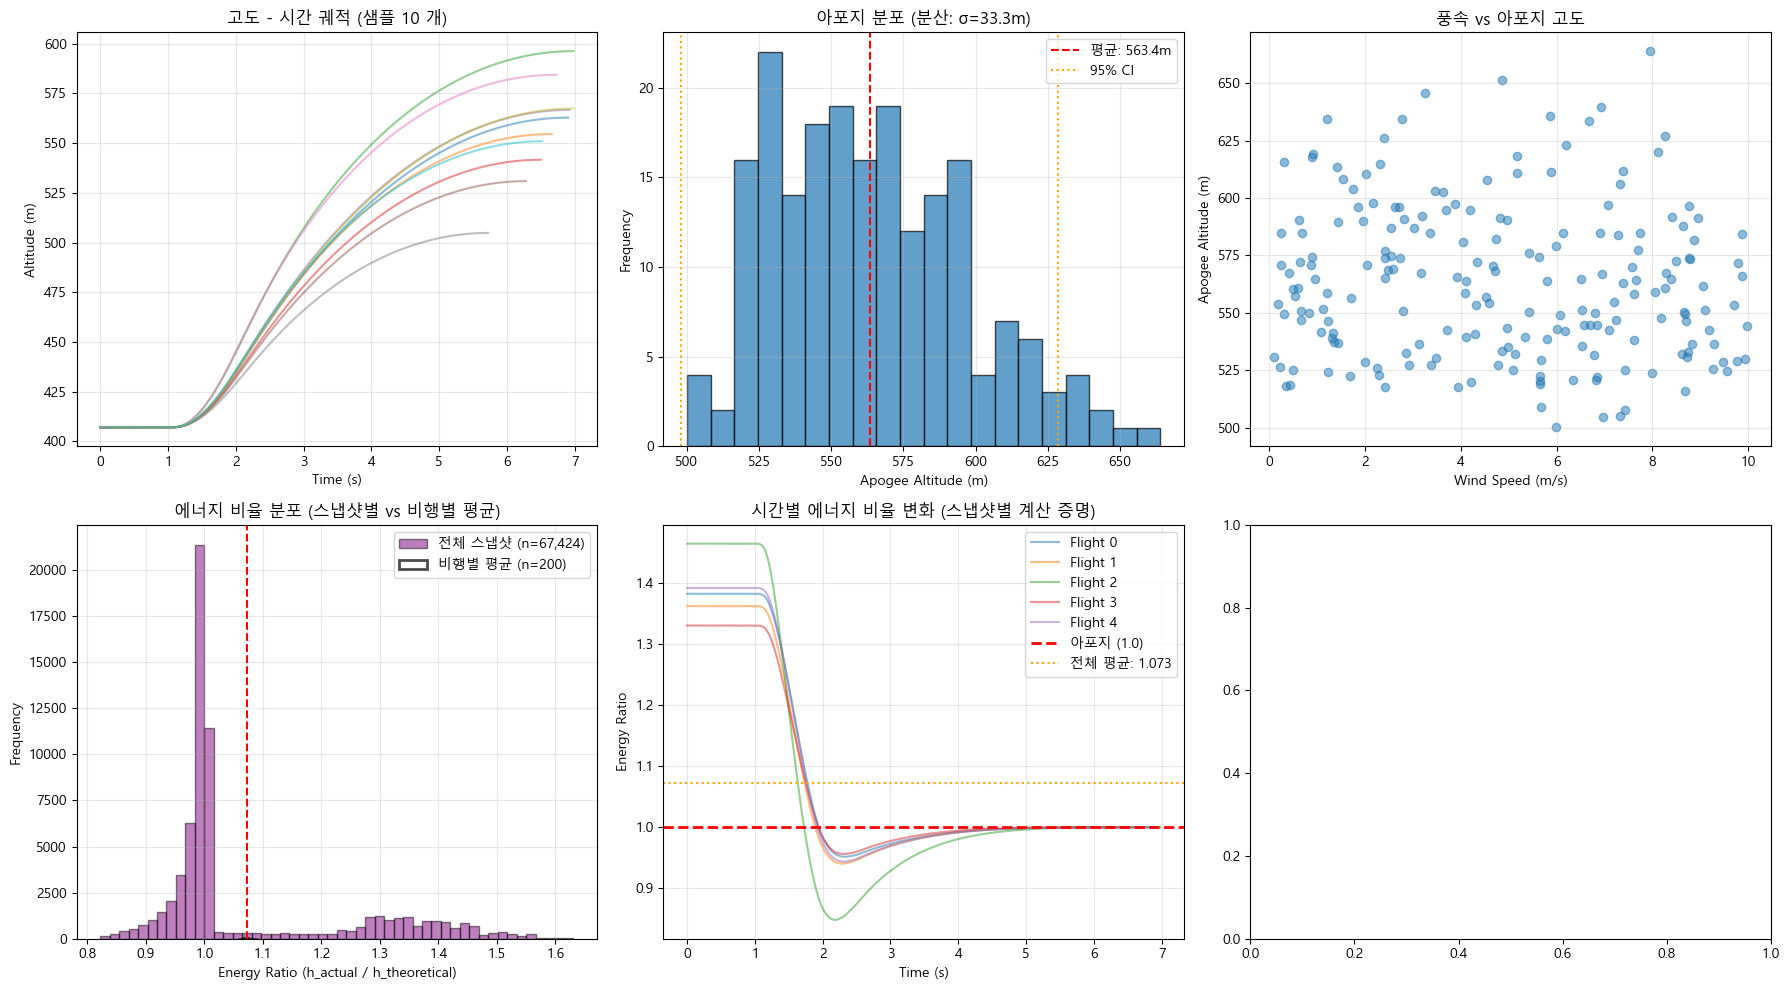


비행 전체 에너지 비율 통계
전체 스냅샷 수: 67,424 개
비행 수: 200 개
스냅샷/비행: 337.1 개

전체 평균: 1.073
전체 표준편차: 0.167
최소: 0.822
최대: 1.631
25% 백분위: 0.985
75% 백분위: 1.094

비행별 평균 평균: 1.0725
비행별 평균 표준편차: 0.0074


In [19]:
def visualize_simulation_results(df_trajectories, df_metadata, actual_flights=None):
    """
    시뮬레이션 결과 시각화 (스냅샷별 에너지 비율 반영)
    
    Parameters:
        df_trajectories: 통합 궤적 데이터
        df_metadata: 메타데이터
        actual_flights: 실제 비행 데이터 (2 개) - Domain Gap 확인용
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. 고도 - 시간 궤적 (샘플 10 개)
    ax1 = axes[0, 0]
    sample_flights = df_trajectories['flight_id'].unique()[:10]
    for fid in sample_flights:
        flight_data = df_trajectories[df_trajectories['flight_id'] == fid]
        ax1.plot(flight_data['time'], flight_data['altitude'], alpha=0.5)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Altitude (m)')
    ax1.set_title('고도 - 시간 궤적 (샘플 10 개)')
    ax1.grid(True, alpha=0.3)
    
    # 2. 아포지 분포 히스토그램 (Step 1 1.2 분산)
    ax2 = axes[0, 1]
    ax2.hist(df_metadata['apogee_altitude'], bins=20, edgecolor='black', alpha=0.7)
    mean_apogee = df_metadata['apogee_altitude'].mean()
    std_apogee = df_metadata['apogee_altitude'].std()
    ax2.axvline(mean_apogee, color='red', linestyle='--', label=f'평균: {mean_apogee:.1f}m')
    ax2.axvline(mean_apogee + 1.96*std_apogee, color='orange', linestyle=':', label='95% CI')
    ax2.axvline(mean_apogee - 1.96*std_apogee, color='orange', linestyle=':')
    ax2.set_xlabel('Apogee Altitude (m)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'아포지 분포 (분산: σ={std_apogee:.1f}m)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 실제 비행 데이터 오버레이 (Domain Gap 확인)
    if actual_flights is not None:
        for i, actual_apogee in enumerate(actual_flights):
            ax2.axvline(actual_apogee, color='green', linestyle='-', linewidth=2, 
                       label=f'실제 비행 {i+1}' if i==0 else "")
    
    # 3. 풍속 vs 아포지 산점도
    ax3 = axes[0, 2]
    ax3.scatter(df_metadata['wind_speed'], df_metadata['apogee_altitude'], alpha=0.5)
    ax3.set_xlabel('Wind Speed (m/s)')
    ax3.set_ylabel('Apogee Altitude (m)')
    ax3.set_title('풍속 vs 아포지 고도')
    ax3.grid(True, alpha=0.3)
    
    # 4. 에너지 비율 분포 (전체 스냅샷 + 비행별 평균)
    ax4 = axes[1, 0]
    
    all_energy_ratios = df_trajectories['energy_ratio']
    ax4.hist(all_energy_ratios, bins=50, alpha=0.5, label=f'전체 스냅샷 (n={len(all_energy_ratios):,})',
             color='purple', edgecolor='black')
    
    # 비행별 평균 분포 (100 개) - 기존 방식과 비교
    flight_mean_ratios = df_trajectories.groupby('flight_id')['energy_ratio'].mean()
    ax4.hist(flight_mean_ratios, bins=20, alpha=0.7, label=f'비행별 평균 (n={len(flight_mean_ratios)})',
             color='orange', edgecolor='black', histtype='step', linewidth=2)
    
    ax4.set_xlabel('Energy Ratio (h_actual / h_theoretical)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('에너지 비율 분포 (스냅샷별 vs 비행별 평균)')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    ax4.axvline(all_energy_ratios.mean(), color='red', linestyle='--', 
               label=f'전체 평균: {all_energy_ratios.mean():.3f}')
    
    # 5. 시간별 에너지 비율 변화 (샘플 5 개 비행)
    ax5 = axes[1, 1]
    sample_flights = df_trajectories['flight_id'].unique()[:5]
    for fid in sample_flights:
        flight_data = df_trajectories[df_trajectories['flight_id'] == fid]
        ax5.plot(flight_data['time'], flight_data['energy_ratio'], alpha=0.5, label=f'Flight {fid}')
    
    ax5.axhline(1.0, color='red', linestyle='--', linewidth=2, label='아포지 (1.0)')
    ax5.axhline(all_energy_ratios.mean(), color='orange', linestyle=':', 
               label=f'전체 평균: {all_energy_ratios.mean():.3f}')
    ax5.set_xlabel('Time (s)')
    ax5.set_ylabel('Energy Ratio')
    ax5.set_title('시간별 에너지 비율 변화 (스냅샷별 계산 증명)')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/visualization_summary.png', dpi=150)
    print(" 시각화 완료: visualization_summary.png")
    plt.show()
    
    # 통계 출력
    print("\n" + "="*60)
    print("비행 전체 에너지 비율 통계")
    print("="*60)
    print(f"전체 스냅샷 수: {len(all_energy_ratios):,} 개")
    print(f"비행 수: {len(df_metadata)} 개")
    print(f"스냅샷/비행: {len(all_energy_ratios) / len(df_metadata):.1f} 개")
    print()
    print(f"전체 평균: {all_energy_ratios.mean():.3f}")
    print(f"전체 표준편차: {all_energy_ratios.std():.3f}")
    print(f"최소: {all_energy_ratios.min():.3f}")
    print(f"최대: {all_energy_ratios.max():.3f}")
    print(f"25% 백분위: {all_energy_ratios.quantile(0.25):.3f}")
    print(f"75% 백분위: {all_energy_ratios.quantile(0.75):.3f}")
    print()
    print(f"비행별 평균 평균: {flight_mean_ratios.mean():.4f}")
    print(f"비행별 평균 표준편차: {flight_mean_ratios.std():.4f}")

visualize_simulation_results(df_all, df_meta)

In [20]:
import gc

def apply_feature_engineering(df_trajectories, df_metadata):
    # 1. 병합 시 필요한 컬럼만 선택해서 메모리 절약
    df = df_trajectories.merge(df_metadata[['flight_id', 'mass_total']], on='flight_id', how='left')
    
    # 메모리 절약을 위해 float32로 변환
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')
    
    # 2. 물리 피처 계산 (In-place로 계산하여 중간 변수 생성 억제)
    g = 9.81
    rho0 = 1.225
    H = 8500

    df['pe'] = (df['mass_total'] * g * df['altitude']).astype('float32')
    df['ke_z'] = (0.5 * df['mass_total'] * (df['velocity_z']**2)).astype('float32')
    df['total_energy'] = df['pe'] + df['ke_z']
    
    # 공기 밀도 및 동압 계산
    air_density = rho0 * np.exp(-df['altitude'] / H)
    df['dynamic_pressure'] = (0.5 * air_density * (df['velocity_total']**2)).astype('float32')
    
    df['jerk_z'] = (df.groupby('flight_id')['acceleration_z'].diff().fillna(0) / 0.02).astype('float32')

    # 불필요한 메모리 정리
    gc.collect() 
    return df

In [21]:
from sklearn.preprocessing import StandardScaler
import joblib

def normalize_features(df):
    """
    AI 학습을 위한 실시간 가용 데이터 정규화
    """
    # [핵심 수정] 
    # 1. acceleration_z(정답) -> acceleration_noisy(센서값)
    # 2. 자이로 노이즈 데이터 3축 추가
    input_features = [
        'altitude_noisy', 
        'acceleration_noisy', 
        'gyro_roll_noisy', 'gyro_pitch_noisy', 'gyro_yaw_noisy', # 추가
        'velocity_z', # KF가 추정해준다고 가정
        'tilt_angle', 
        'dynamic_pressure', 'total_energy', 'jerk_z'
    ]
    
    target_labels = ['energy_ratio', 'time_to_apogee']
    
    # 메모리 효율을 위해 원본 수정
    scaler_input = StandardScaler()
    
    # 피처가 데이터프레임에 모두 존재하는지 확인
    missing = [f for f in input_features if f not in df.columns]
    if missing:
        raise KeyError(f"데이터프레임에 다음 피처가 누락되었습니다: {missing}")

    # float32 변환과 함께 정규화 적용
    df[input_features] = scaler_input.fit_transform(df[input_features]).astype('float32')
    
    # 모델 디렉토리 생성 및 Scaler 저장
    os.makedirs('./models/', exist_ok=True)
    joblib.dump(scaler_input, './models/input_scaler.pkl')
    
    import gc
    gc.collect()
    
    return df, input_features, target_labels

In [22]:
df_enriched = apply_feature_engineering(df_all, df_meta)

# 정규화 적용
df_final, features, labels = normalize_features(df_enriched)

# 사용이 끝난 객체 삭제
del df_enriched
gc.collect()

# 저장 (이때 압축률을 높이면 디스크 용량도 절약됨)
df_final.to_csv('./data/simulated/processed_trajectories.csv.gz', 
                index=False, compression='gzip')

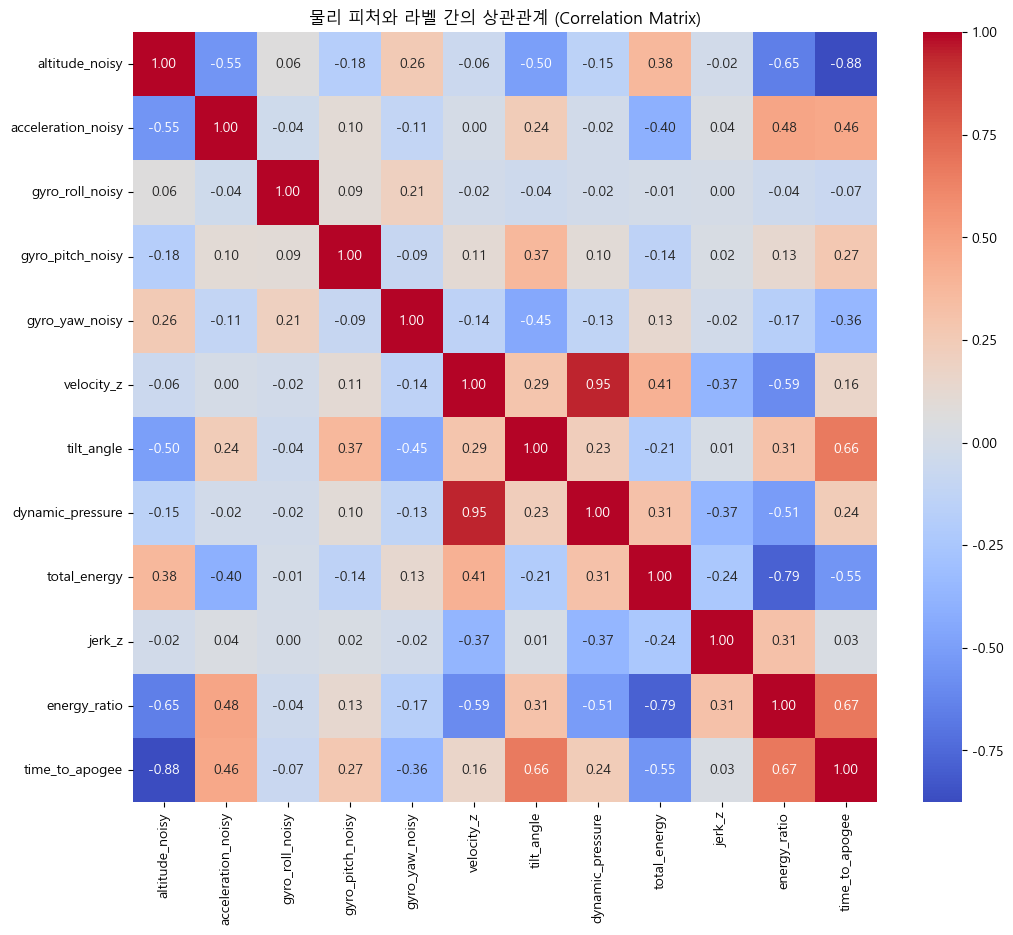

In [23]:
# [Mission] 피처 간의 상관관계 시각화하기
import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 행렬 계산
corr = df_final[features + labels].corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("물리 피처와 라벨 간의 상관관계 (Correlation Matrix)")
plt.show()

### Step 1.5 실습

#### 1: 기본 파이프라인 실행
1. `n_flights=100` 으로 테스트 데이터 생성
2. 아포지 분포 히스토그램 확인 (Step 1 1.2 분산 개념 적용)
3. 표준편차와 95% 신뢰구간 계산

#### 2: 노이즈 민감도 분석
1. 고도 노이즈 σ 를 0.1m → 2.0m 로 변경하며 재실행
2. 노이즈 크기가 아포지 예측 오차에 미치는 영향 분석
3. Step 1 1.2 분산 개념으로 결과 해석

#### 3: 실제 데이터와 Domain Gap 확인
1. 실제 비행 2 개의 아포지 고도를 시뮬레이션 분포와 비교
2. Gap 이 크다면 어떤 파라미터 (Cd, 질량, 등) 를 보정해야 할지 논의
3. 보정 방안 제안 (파라미터 튜닝, 노이즈 모델 수정 등)